In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cross_decomposition import PLSCanonical
import umap
import phate

from src import utils

In [2]:
# path = 'Data/20260211/'
path = 'Data/20260224'
emb_dir = f"{path}/embeddings"

In [103]:
# Load everything precomputed by compute_master_npz.py
master = np.load(f"{path}/master.npz", allow_pickle=True)

filtered_ids   = master['ids']
filtered_times = master['times']
filtered_areas = master['areas']            # true area (m.area)
l_cross_values = master['l_cross_values']   # complexity (degree L)
filtered_hks   = master['hks_bof_coeffs__kmeans_variable']   # (N, n_modes^2, n_vocab)
# filtered_hks   = master['hks_bof_coeffs__pca_variable']   # (N, n_modes^2, n_vocab)

print(filtered_hks.shape)

(3231, 225, 8)


In [104]:
df = pd.read_csv('Data/cell_types_norm_neg.csv')
print(df.shape) 

common_ids = np.intersect1d(df['label_uid'].values, np.array(filtered_ids))
print(f"Number of common ids: {len(common_ids)}")

filter_indices = np.isin(filtered_ids, common_ids)
filtered_ids = filtered_ids[filter_indices]
filtered_times = filtered_times[filter_indices]
filtered_areas = filtered_areas[filter_indices]
l_cross_values = l_cross_values[filter_indices]
filtered_hks = filtered_hks[filter_indices]

# reorder df according to filtered_ids 
df = df.set_index('label_uid').reindex(filtered_ids).reset_index()
print(df.columns[-10:-1])
percentages = df[df.columns[-10:-1]].values

assert np.all(df['label_uid'] == filtered_ids)

np.savetxt('Data/organoid_uid_list.txt', filtered_ids, fmt='%s')

(2859, 18)
Number of common ids: 2599
Index(['LGR.cnt_exclusive', 'CHROMA.cnt_exclusive', 'TA.cnt_exclusive',
       'MUC.cnt_exclusive', 'ALDOB.cnt_exclusive', 'GLUC.cnt_exclusive',
       'AGR.cnt_exclusive', 'SERO.cnt_exclusive', 'LYZ.cnt_exclusive'],
      dtype='object')


In [105]:
num_degree = int(np.sqrt(filtered_hks.shape[1]))
hks_power_spectrum = np.zeros((filtered_hks.shape[0], num_degree, filtered_hks.shape[2]))

for n in range(num_degree):
    start_idx = n**2
    end_idx = (n+1)**2
    # Sum of squared coefficients between l = n^2 and (n+1)^2
    hks_power_spectrum[:, n, :] = np.sum(filtered_hks[:, start_idx:end_idx, :]**2, axis=1)

print(hks_power_spectrum.shape)

(2599, 15, 8)


In [106]:
hks_power_spectrum /= np.max(hks_power_spectrum, axis=(0,1), keepdims=True)  # Normalize HKS by its maximum value across all samples and degrees
coeffs = hks_power_spectrum

hks_names = [f'hks-{i}' for i in range(hks_power_spectrum.shape[-1])]
names = hks_names
print(names)

['hks-0', 'hks-1', 'hks-2', 'hks-3', 'hks-4', 'hks-5', 'hks-6', 'hks-7']


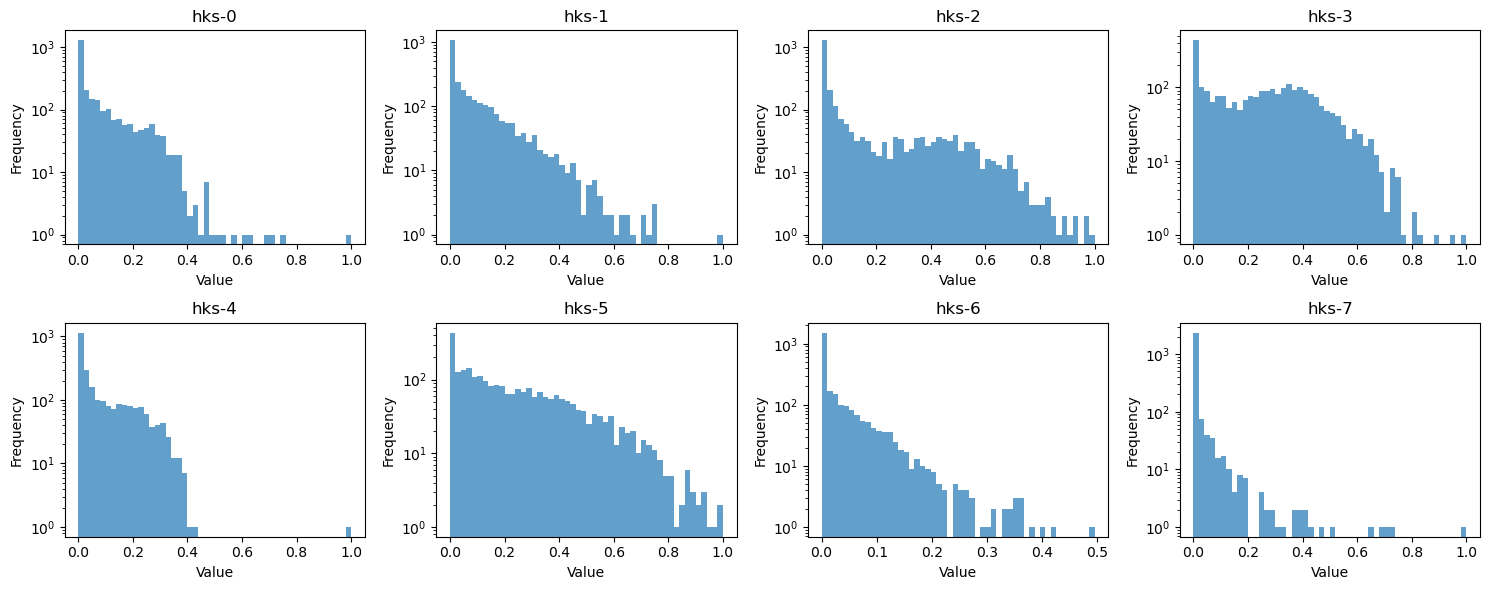

In [107]:
num_features = coeffs.shape[-1]
ncols = 4
nrows = (num_features + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows))
axes = axes.flatten()

for i in range(num_features):
    axes[i].hist(coeffs[:, 0, i], bins=50, alpha=0.7)
    axes[i].set_title(names[i])
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].set_yscale('log')  # Use logarithmic scale for better visibility

# Hide unused subplots
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

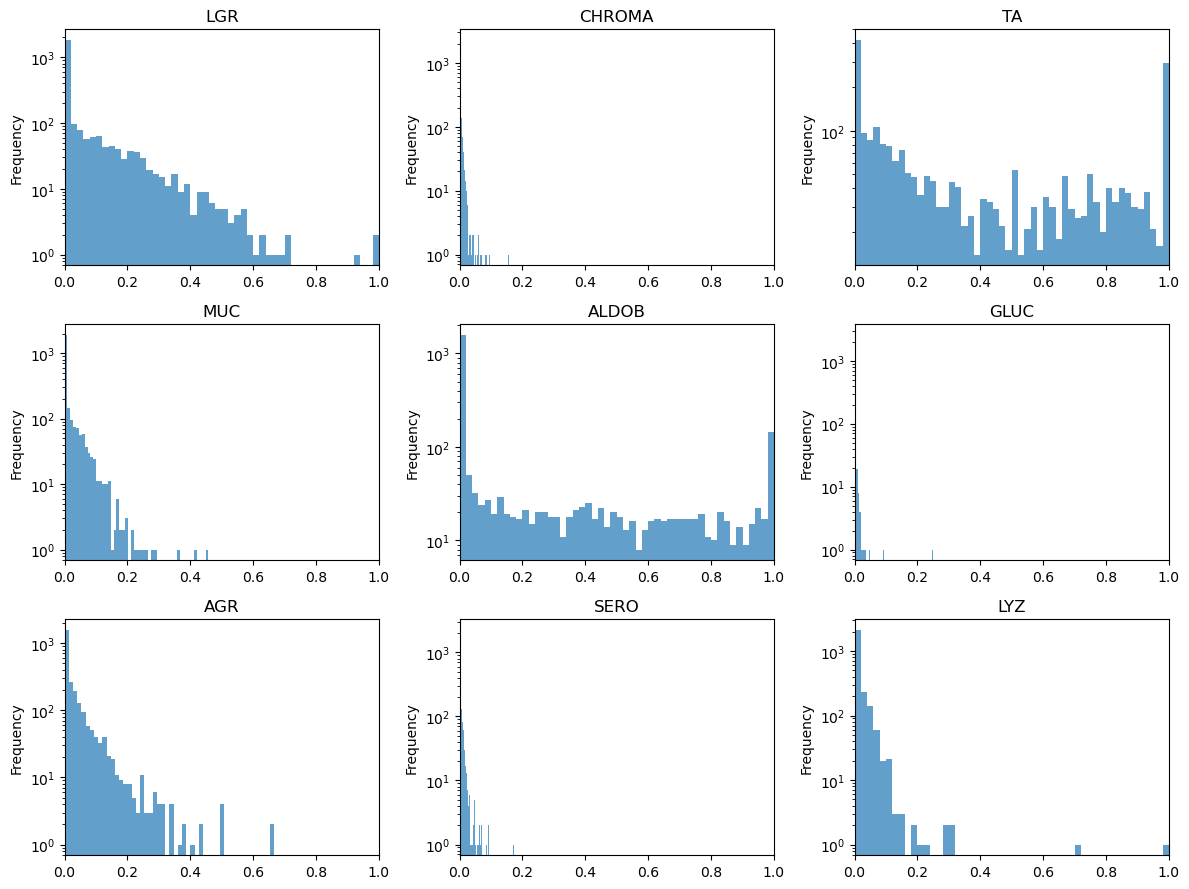

In [108]:
col_names = [c.split('.')[0] for c in df.columns[-10:-1]]
ncols = 3
nrows = (percentages.shape[1] + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()

for i in range(percentages.shape[1]):
    axes[i].hist(percentages[:, i], bins=50, alpha=0.7)
    axes[i].set_title(col_names[i])
    axes[i].set_ylabel('Frequency')
    axes[i].set_yscale('log')
    axes[i].set_xlim([0, 1])

for j in range(percentages.shape[1], len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [109]:
remainder = 1 - percentages.sum(axis=1, keepdims=True)
percentages_full = np.hstack([percentages, remainder])

# lgr/sero/lyz presence-absence combo (8-way categorical label).
# col_names order: [LGR, CHROMA, TA, MUC, ALDOB, GLUC, AGR, SERO, LYZ]
fate_markers3 = {'lgr': 0, 'sero': 7, 'lyz': 8}   # cols in percentages_full
present = {m: percentages_full[:, j] > 0 for m, j in fate_markers3.items()}
fate_combo = np.array([f"lgr{'+' if l else '-'} sero{'+' if s else '-'} lyz{'+' if z else '-'}"
                       for l, s, z in zip(present['lgr'], present['sero'], present['lyz'])])
fate_combo_codes, fate_combo_uniques = pd.factorize(fate_combo)
print(dict(zip(*np.unique(fate_combo, return_counts=True))))

{'lgr+ sero+ lyz+': 384, 'lgr+ sero+ lyz-': 69, 'lgr+ sero- lyz+': 283, 'lgr+ sero- lyz-': 213, 'lgr- sero+ lyz+': 31, 'lgr- sero+ lyz-': 32, 'lgr- sero- lyz+': 144, 'lgr- sero- lyz-': 1443}


In [110]:
# subsample by timepoint

print("Unique timepoints:", np.unique(filtered_times))

# count how many samples fall into each timepoint
timepoint_counts = pd.Series(filtered_times).value_counts()
print("Timepoint counts:", timepoint_counts)

Unique timepoints: ['1p5' '2' '2p5' '3' '3p5' '4' '4p5' '4p5-more']
Timepoint counts: 3           459
4p5-more    408
1p5         378
2p5         364
4           326
3p5         300
2           275
4p5          89
Name: count, dtype: int64


In [111]:
def ilr_transform(X, eps=1e-6):
    X = np.asarray(X, dtype=float)
    X = X / X.sum(axis=1, keepdims=True)
    # multiplicative zero replacement: preserve sum=1
    zero_mask = X <= 0
    n_zeros = zero_mask.sum(axis=1, keepdims=True)
    X = np.where(zero_mask, eps, X * (1 - eps * n_zeros))
    # CLR
    log_x = np.log(X)
    clr = log_x - log_x.mean(axis=1, keepdims=True)
    # Helmert basis (D, D-1)
    D = X.shape[1]
    j = np.arange(1, D)
    a = 1.0 / np.sqrt(j * (j + 1))
    V = np.zeros((D, D - 1))
    for col, (jj, aa) in enumerate(zip(j, a)):
        V[:jj, col] = aa
        V[jj, col] = -jj * aa
    return clr @ V

percentages_ilr = ilr_transform(percentages_full)
print(percentages_ilr.shape)  # (N, D-1)

(2599, 9)


In [112]:
method = 'umap'  # 'tsne' | 'umap' | 'phate' | 'pca'

if method == 'tsne':
    percentages_emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(percentages_ilr)
elif method == 'umap':
    percentages_emb = umap.UMAP(n_components=2, random_state=42, n_neighbors=50, min_dist=1).fit_transform(percentages_ilr)
elif method == 'phate':
    import phate
    temp = percentages_ilr + np.random.normal(0, 1e-5, size=percentages_ilr.shape)  # add small noise for stability
    percentages_emb = phate.PHATE(n_components=2, random_state=42, knn=30, t=30).fit_transform(temp)
elif method == 'pca':
    percentages_emb = PCA(n_components=2).fit_transform(percentages_ilr)

utils.save_embedding(emb_dir, "percentages_emb", percentages_emb, filtered_ids, method,
                     times=filtered_times, l_cross=l_cross_values, areas=filtered_areas)

/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


'Data/20260224/embeddings/percentages_emb.npz'

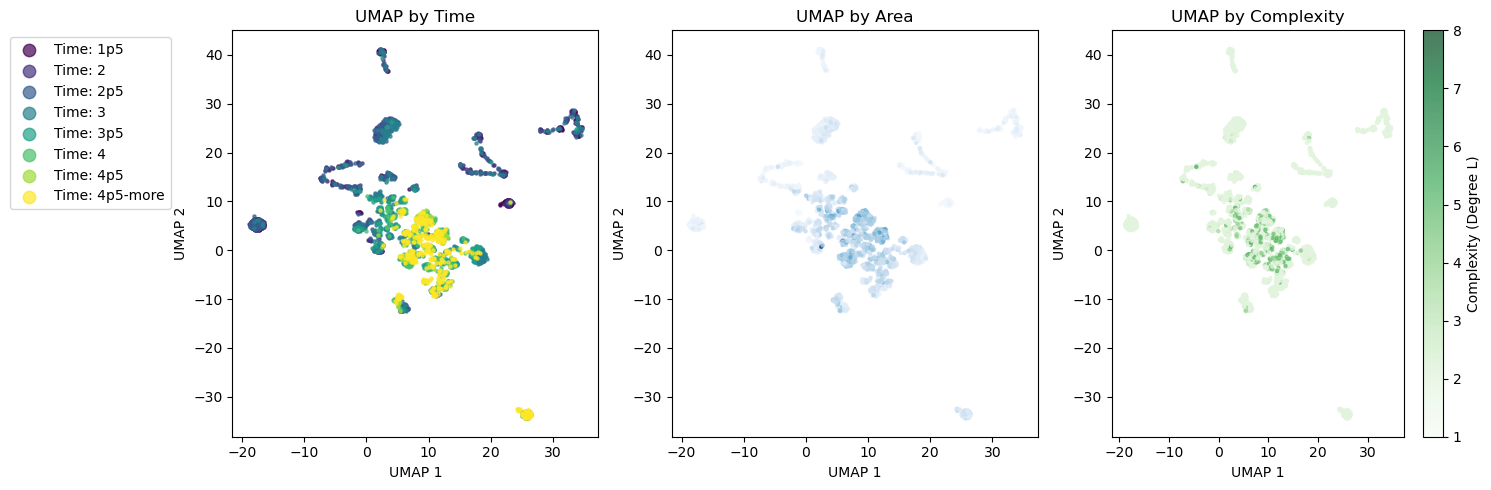

In [113]:
# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
unique_times = np.unique(filtered_times)
point_size = 5

cmap_time = plt.get_cmap('viridis')
for i, t in enumerate(unique_times):
    mask = filtered_times == t
    color = cmap_time(i / (len(unique_times) - 1))
    axes[0].scatter(percentages_emb[mask, 0], percentages_emb[mask, 1], color=color, alpha=0.7, s=point_size, label=f"Time: {t}")
axes[0].set_title(f'{method.upper()} by Time')
axes[0].set_xlabel(f'{method.upper()} 1')
axes[0].set_ylabel(f'{method.upper()} 2')
axes[0].legend(bbox_to_anchor=(-0.15, 1), loc='upper right', markerscale=4)

axes[1].scatter(percentages_emb[:, 0], percentages_emb[:, 1], c=filtered_areas, cmap='Blues', alpha=0.7, s=point_size)
axes[1].set_title(f'{method.upper()} by Area')
axes[1].set_xlabel(f'{method.upper()} 1')
axes[1].set_ylabel(f'{method.upper()} 2')   

sc_tsne_complex = axes[-1].scatter(percentages_emb[:, 0], percentages_emb[:, 1], c=l_cross_values, cmap='Greens', alpha=0.7, s=point_size, vmin=1, vmax=8)
axes[-1].set_title(f'{method.upper()} by Complexity')
axes[-1].set_xlabel(f'{method.upper()} 1')
axes[-1].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc_tsne_complex, ax=axes[-1], label='Complexity (Degree L)')

plt.tight_layout()
plt.show()

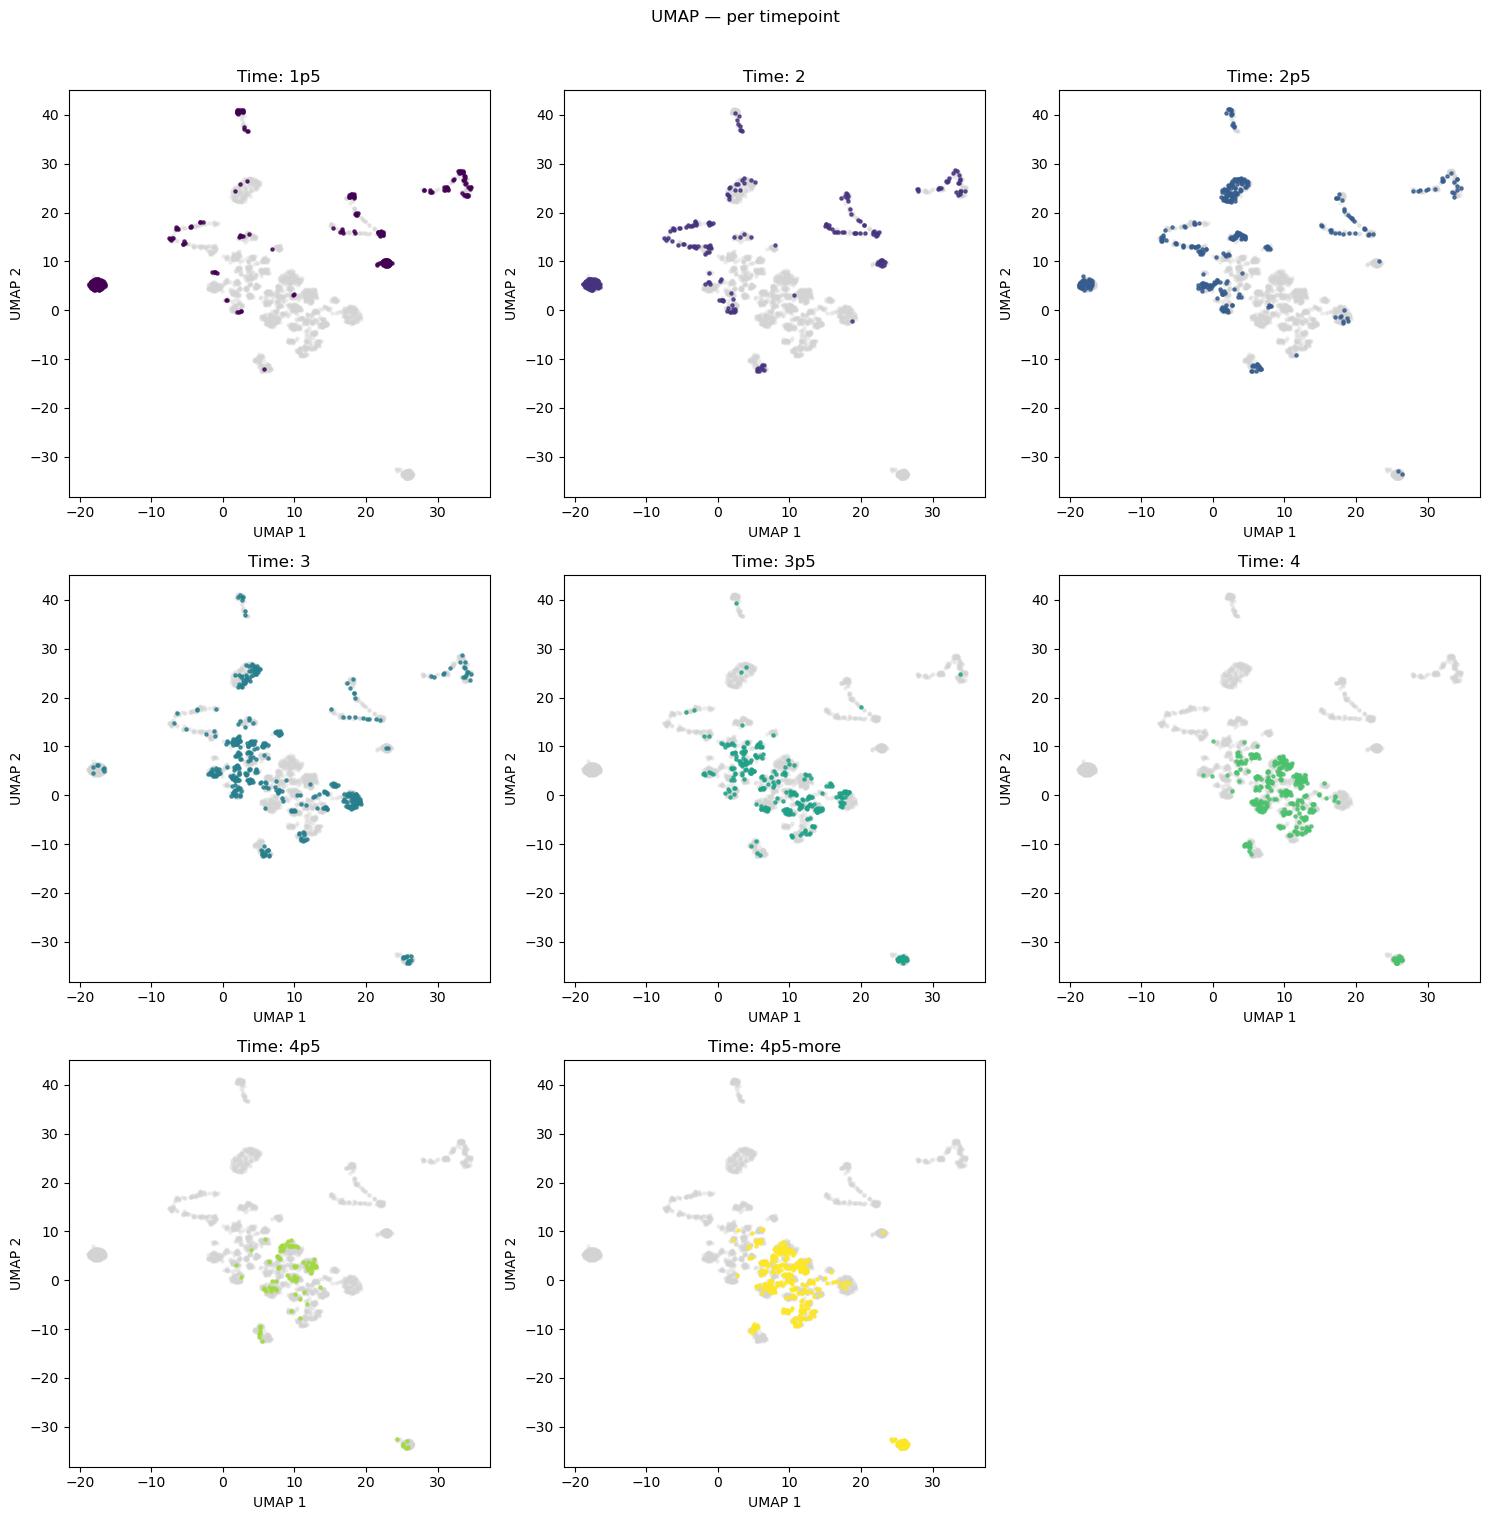

In [35]:
unique_times = np.unique(filtered_times)
ncols = 3
nrows = (len(unique_times) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = axes.flatten()

cmap_time = plt.get_cmap('viridis')
for i, t in enumerate(unique_times):
    mask = filtered_times == t
    color = cmap_time(i / (len(unique_times) - 1))
    axes[i].scatter(percentages_emb[~mask, 0], percentages_emb[~mask, 1], color='lightgrey', alpha=0.3, s=point_size)
    axes[i].scatter(percentages_emb[mask, 0], percentages_emb[mask, 1], color=color, alpha=0.8, s=point_size)
    axes[i].set_title(f'Time: {t}')
    axes[i].set_xlabel(f'{method.upper()} 1')
    axes[i].set_ylabel(f'{method.upper()} 2')

for j in range(len(unique_times), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'{method.upper()} — per timepoint', y=1.01)
plt.tight_layout()
plt.show()

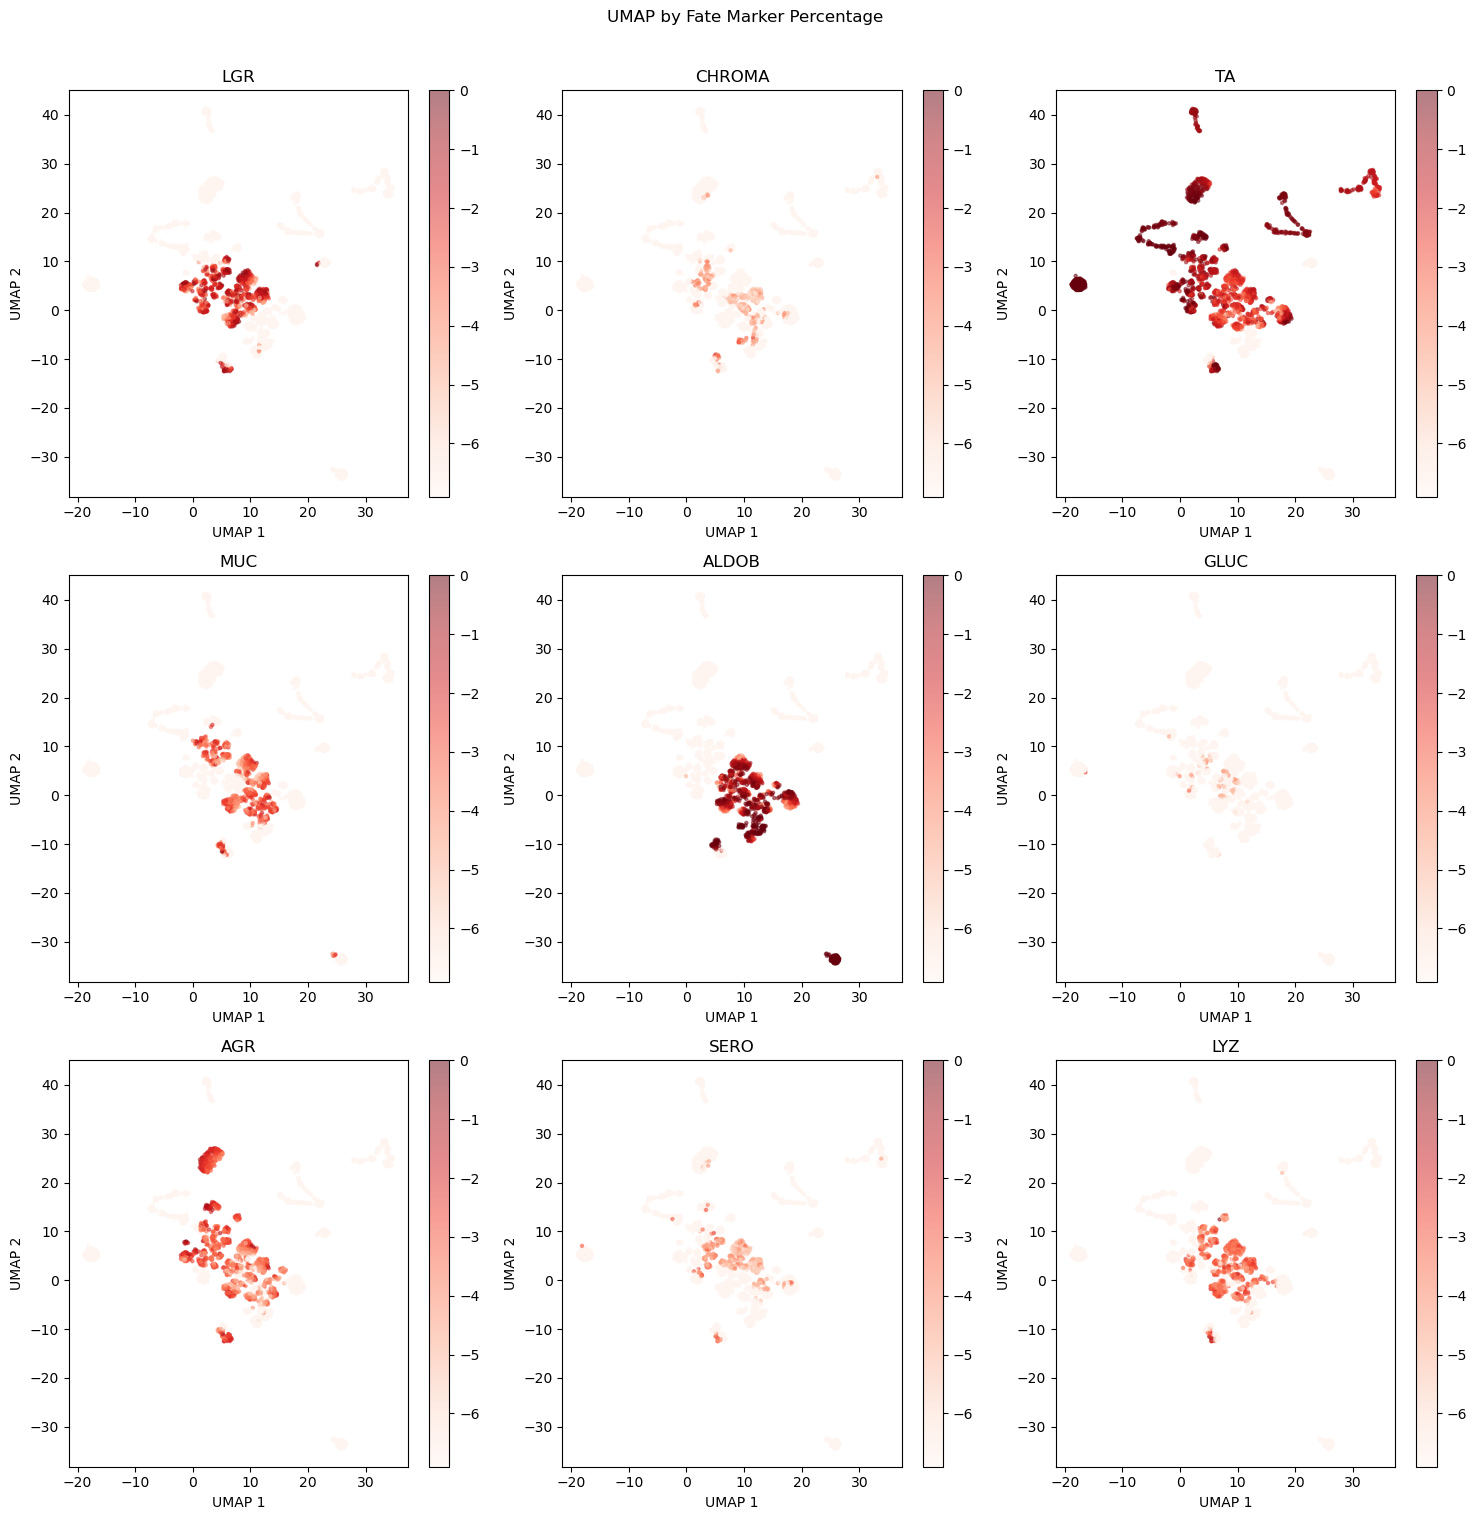

In [36]:
ncols = 3
nrows = (percentages_ilr.shape[1] + ncols - 1) // ncols

log_perc = np.log(percentages_full + 1e-3)
vmin, vmax = log_perc.min(), log_perc.max()

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i in range(percentages_ilr.shape[1]):
    sc = axes[i].scatter(percentages_emb[:, 0], percentages_emb[:, 1], c=log_perc[:, i],
                         cmap='Reds', alpha=0.5, s=point_size, vmin=vmin, vmax=vmax)
    axes[i].set_title(col_names[i])
    axes[i].set_xlabel(f'{method.upper()} 1')
    axes[i].set_ylabel(f'{method.upper()} 2')
    fig.colorbar(sc, ax=axes[i])

for j in range(percentages_ilr.shape[1], len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'{method.upper()} by Fate Marker Percentage', y=1.01)
plt.tight_layout()
plt.show()

In [154]:
weights_vocab = np.sqrt(np.array([2, 2, 0.01, 0.5, 0.01, 0.5, 1, 1]))
# weights_vocab = np.sqrt(np.array([1, 1, 0.5]))
weights_modes = np.ones(hks_power_spectrum.shape[1])
weights_modes[1:] *= np.sqrt(2)
hks_power_spectrum_scaled = hks_power_spectrum * weights_vocab[np.newaxis, np.newaxis, :] * weights_modes[np.newaxis, :, np.newaxis]
hks_reshaped = hks_power_spectrum_scaled.reshape(hks_power_spectrum_scaled.shape[0], -1)

complexity_mask = l_cross_values >= 0

In [155]:
shape_features = hks_reshaped[complexity_mask]  # only use HKS features, no area
method = 'umap' 
if method == 'tsne':
    emb = TSNE(n_components=2, random_state=42, perplexity=30)
    hks_emb = emb.fit_transform(shape_features)
elif method == 'umap':
    hks_emb = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=1).fit_transform(shape_features)
elif method == 'phate':
    hks_emb = phate.PHATE(n_components=2, random_state=42, knn=5, t=10, gamma=0).fit_transform(shape_features)
elif method == 'pca':
    hks_emb = PCA(n_components=2).fit_transform(shape_features)

# KMeans on the ORIGINAL shape coordinates (not the 2D embedding)
from sklearn.cluster import KMeans
n_shape_clusters = 20  # edit me
shape_clusters = KMeans(n_clusters=n_shape_clusters, random_state=42, n_init=10).fit_predict(shape_features)

utils.save_embedding(emb_dir, "hks_full_emb", hks_emb, filtered_ids[complexity_mask], method,
                     times=filtered_times[complexity_mask], l_cross=l_cross_values[complexity_mask],
                     areas=filtered_areas[complexity_mask], shape_cluster=shape_clusters)

/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


'Data/20260224/embeddings/hks_full_emb.npz'

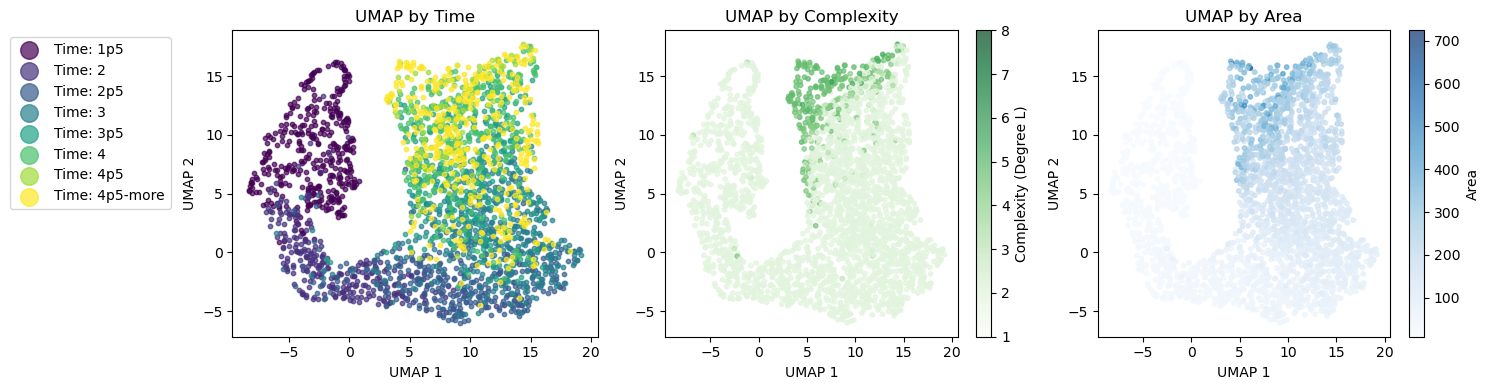

In [156]:
# Figure 1: Time and Complexity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
point_size = 10

cmap_time = plt.get_cmap('viridis')
for i, t in enumerate(unique_times):
    mask = filtered_times[complexity_mask] == t
    color = cmap_time(i / (len(unique_times) - 1))
    axes[0].scatter(hks_emb[mask, 0], hks_emb[mask, 1], color=color, alpha=0.7, s=point_size, label=f"Time: {t}")
axes[0].set_title(f'{method.upper()} by Time')
axes[0].set_xlabel(f'{method.upper()} 1')
axes[0].set_ylabel(f'{method.upper()} 2')
axes[0].legend(bbox_to_anchor=(-0.15, 1), loc='upper right', markerscale=4)

sc = axes[1].scatter(hks_emb[:, 0], hks_emb[:, 1], c=l_cross_values[complexity_mask], cmap='Greens', alpha=0.7, s=point_size, vmin=1, vmax=8)
axes[1].set_title(f'{method.upper()} by Complexity')
axes[1].set_xlabel(f'{method.upper()} 1')
axes[1].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[1], label='Complexity (Degree L)')

sc = axes[2].scatter(hks_emb[:, 0], hks_emb[:, 1], c=filtered_areas[complexity_mask], cmap='Blues', alpha=0.7, s=point_size)
axes[2].set_title(f'{method.upper()} by Area')
axes[2].set_xlabel(f'{method.upper()} 1')
axes[2].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[2], label='Area')

plt.tight_layout()
plt.show()

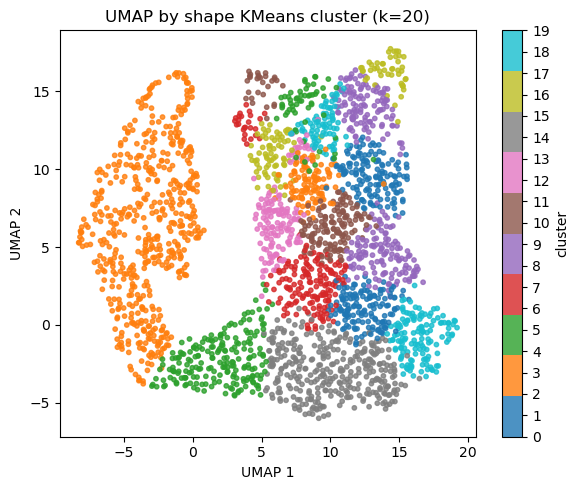

In [157]:
# Shape embedding coloured by KMeans cluster (clusters from original HKS coords)
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(hks_emb[:, 0], hks_emb[:, 1], c=shape_clusters, cmap='tab10',
                alpha=0.8, s=point_size)
ax.set_title(f'{method.upper()} by shape KMeans cluster (k={n_shape_clusters})')
ax.set_xlabel(f'{method.upper()} 1'); ax.set_ylabel(f'{method.upper()} 2')
cbar = fig.colorbar(sc, ax=ax, ticks=range(n_shape_clusters), label='cluster')
plt.tight_layout()
plt.show()

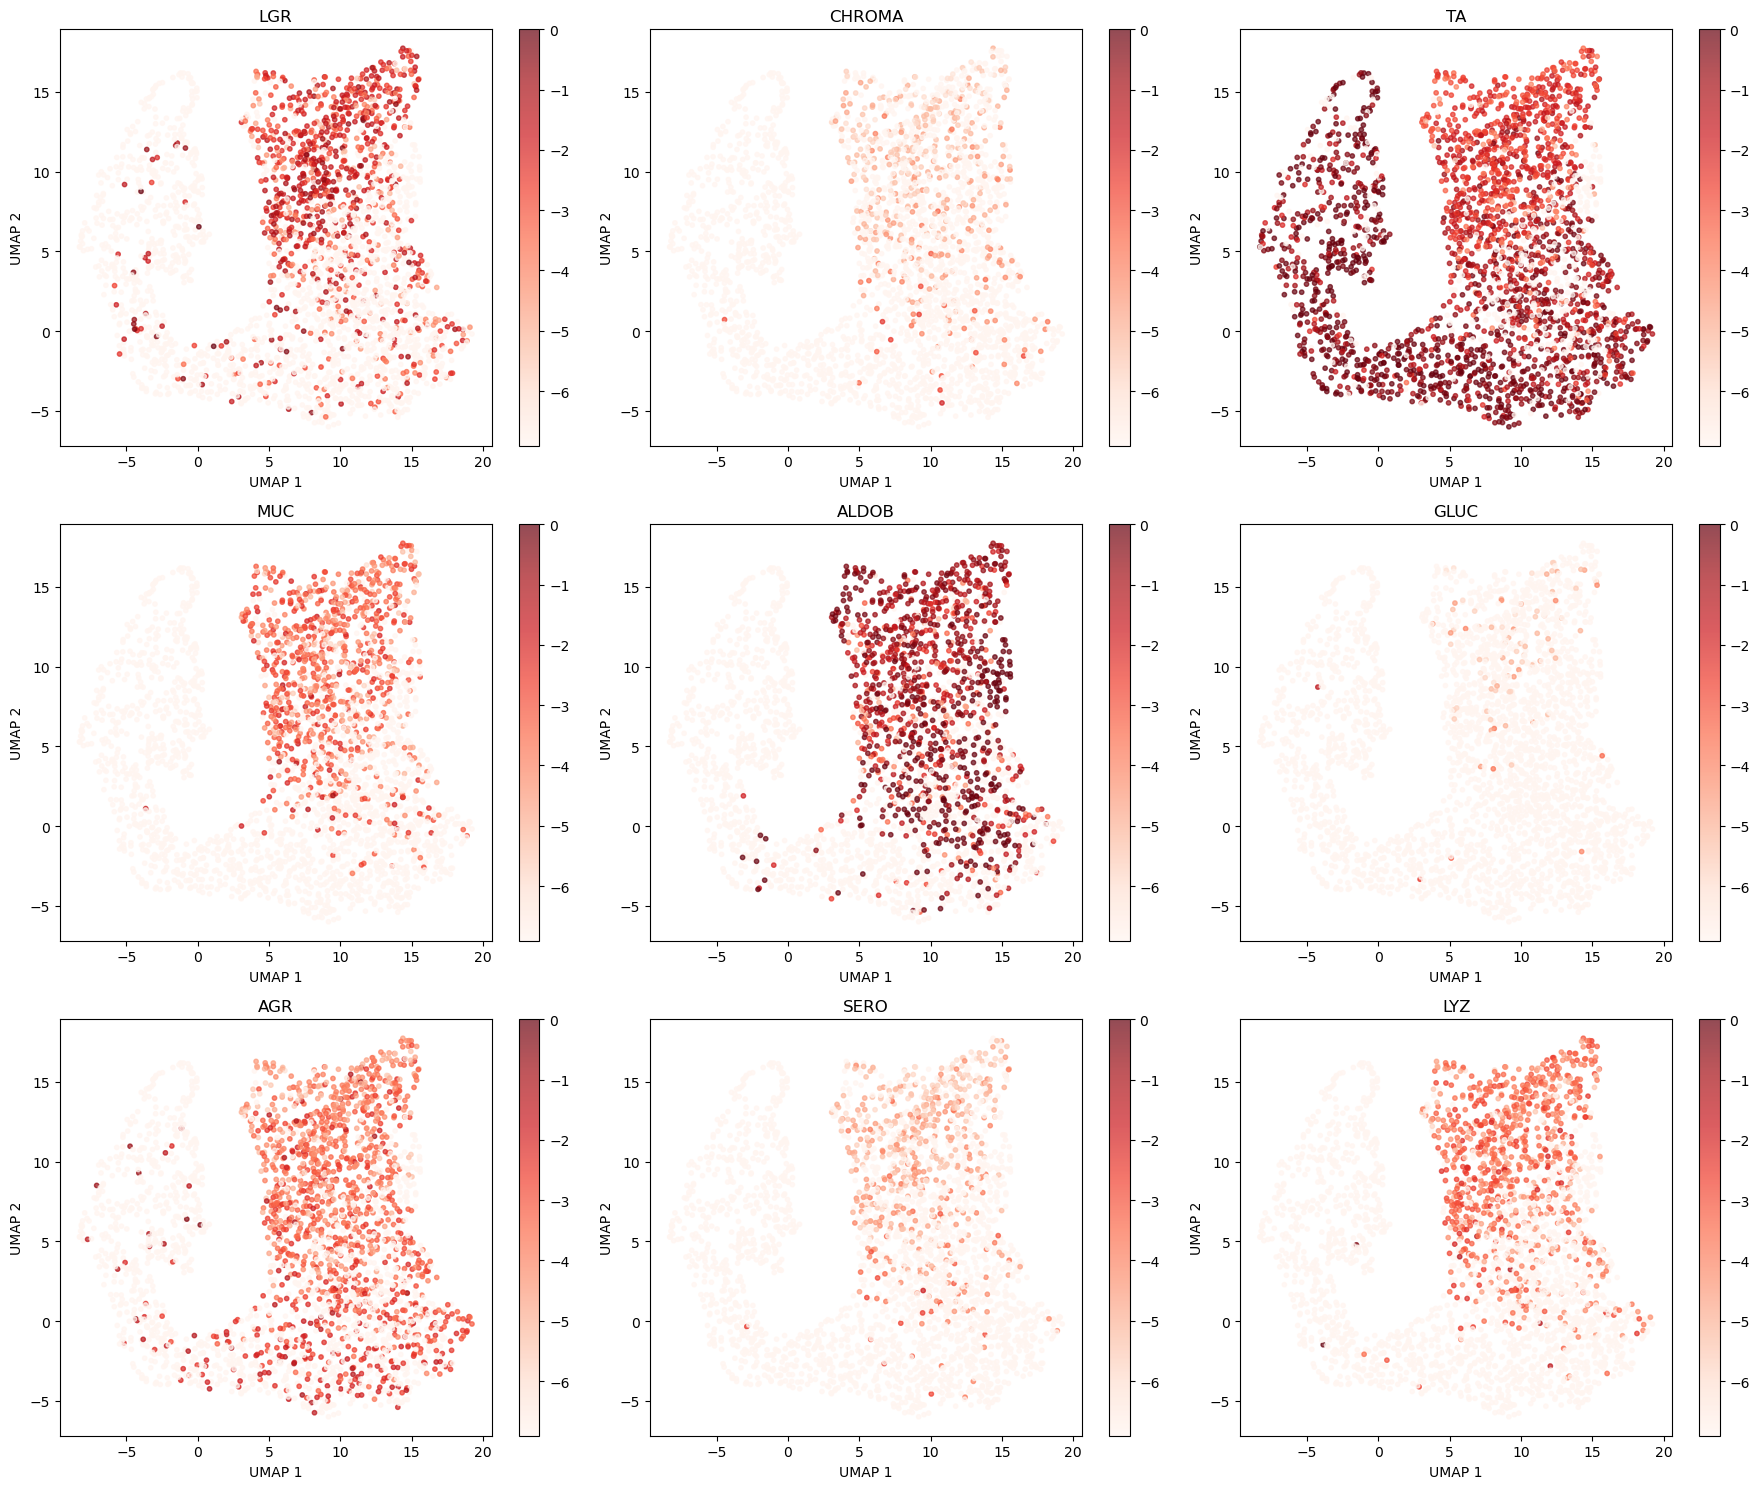

In [158]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

vmin = np.log(percentages_full + 1e-3).min()
vmax = np.log(percentages_full + 1e-3).max()

for i in range(percentages_full.shape[1]-1):
    sc = axes[i].scatter(hks_emb[:, 0], hks_emb[:, 1], c=np.log(percentages_full[complexity_mask, i]+1e-3), cmap='Reds', alpha=0.7, s=point_size, vmin=vmin, vmax=vmax)
    axes[i].set_title(col_names[i])
    axes[i].set_xlabel(f'{method.upper()} 1')
    axes[i].set_ylabel(f'{method.upper()} 2')
    fig.colorbar(sc, ax=axes[i])

plt.tight_layout()
plt.show()

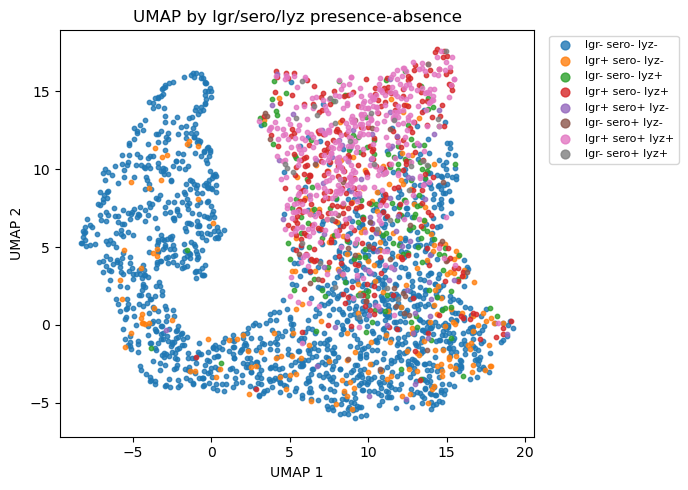

In [159]:
# Shape embedding coloured by lgr/sero/lyz presence-absence combo
fig, ax = plt.subplots(figsize=(7, 5))
codes_m = fate_combo_codes[complexity_mask]
cmap_combo = plt.get_cmap('tab10')
for code in np.unique(fate_combo_codes):
    mask = codes_m == code
    if not mask.any():
        continue
    ax.scatter(hks_emb[mask, 0], hks_emb[mask, 1], color=cmap_combo(code % 10),
               alpha=0.8, s=point_size, label=fate_combo_uniques[code])
ax.set_title(f'{method.upper()} by lgr/sero/lyz presence-absence')
ax.set_xlabel(f'{method.upper()} 1'); ax.set_ylabel(f'{method.upper()} 2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

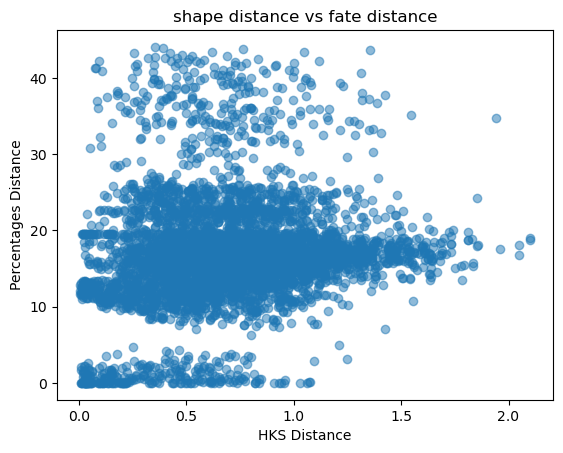

In [160]:
# randomly select 1000 pairs of samples to compute distances
num_samples = hks_reshaped.shape[0]
num_pairs = 5000
sample_indices = np.random.choice(num_samples, size=(num_pairs, 2), replace=True)

hks_dist = np.linalg.norm(hks_reshaped[sample_indices[:, 0]]- hks_reshaped[sample_indices[:, 1]], axis=1)
perc_dist = np.linalg.norm(percentages_ilr[sample_indices[:, 0]]- percentages_ilr[sample_indices[:, 1]], axis=1)

mean_hks_dist = np.mean(hks_dist)
mean_perc_dist = np.mean(perc_dist)

plt.plot(hks_dist.flatten(), perc_dist.flatten(), 'o', alpha=0.5)
plt.xlabel('HKS Distance')
plt.ylabel('Percentages Distance')
plt.title('shape distance vs fate distance')
plt.show()  

hks_normalised = hks_reshaped  / mean_hks_dist
percentages_normalised = percentages_ilr / mean_perc_dist

X scores: (2599, 2), Y scores: (2599, 2)


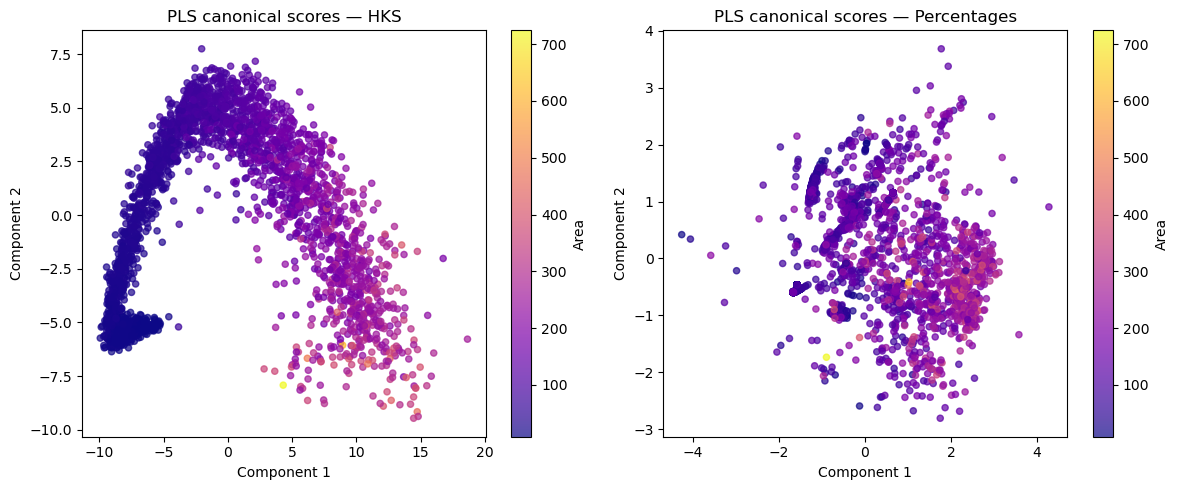

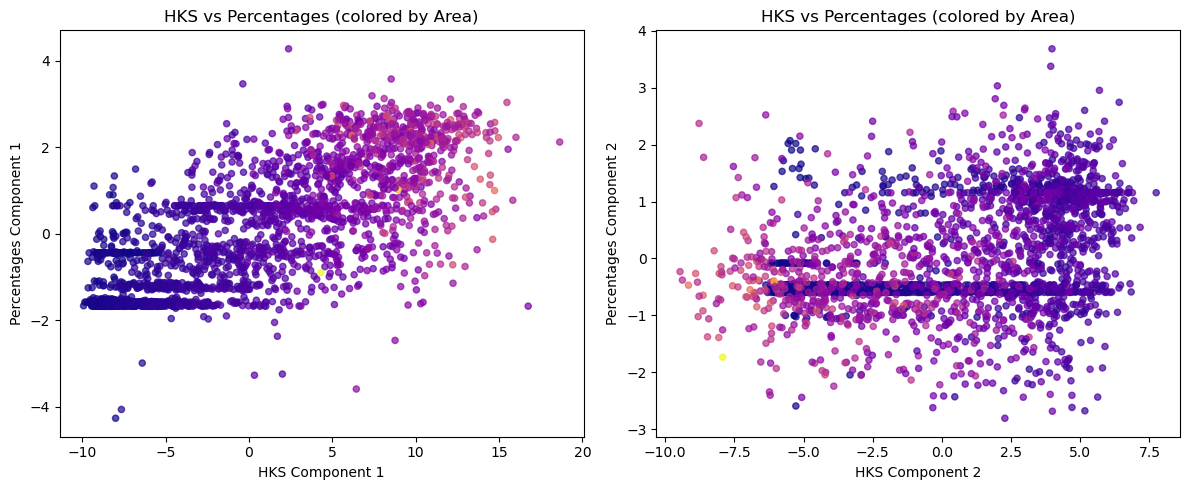

In [161]:
X_pls = hks_normalised
Y_pls = percentages_normalised

pls = PLSCanonical(n_components=2, max_iter=1000)
pls.fit(X_pls, Y_pls)
X_c, Y_c = pls.transform(X_pls, Y_pls)
print(f"X scores: {X_c.shape}, Y scores: {Y_c.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, scores, label in zip(axes, [X_c, Y_c], ['HKS', 'Percentages']):
    sc = ax.scatter(scores[:, 0], scores[:, 1], c=filtered_areas, cmap='plasma', alpha=0.7, s=20)
    ax.set_title(f'PLS canonical scores — {label}')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    fig.colorbar(sc, ax=ax, label='Area')
plt.tight_layout()
plt.show()

# plot hks component 1 vs percentages component 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i in range(2): 
    axes[i].scatter(X_c[:, i], Y_c[:, i], c=filtered_areas, cmap='plasma', alpha=0.7, s=20)
    axes[i].set_xlabel(f'HKS Component {i+1}')
    axes[i].set_ylabel(f'Percentages Component {i+1}')
    axes[i].set_title(f'HKS vs Percentages (colored by Area)')
plt.tight_layout()
plt.show()

In [179]:
area_normalised = (filtered_areas - np.min(filtered_areas)) / (np.max(filtered_areas) - np.min(filtered_areas))
X  = np.concatenate((hks_normalised, percentages_normalised, area_normalised[:, np.newaxis]), axis=1) 

method = 'umap' 
if method == 'tsne':
    emb = TSNE(n_components=2, random_state=42)
    X_emb = emb.fit_transform(X)
elif method == 'umap':
    X_emb = umap.UMAP(n_components=2, random_state=10, n_neighbors=20, min_dist=1).fit_transform(X)
elif method == 'phate':
    X_emb = phate.PHATE(n_components=2, random_state=42, knn=50, t=30).fit_transform(X)
elif method == 'pca':
    X_emb = PCA(n_components=2).fit_transform(X)

utils.save_embedding(emb_dir, "X_emb", X_emb, filtered_ids, method,
                     times=filtered_times, l_cross=l_cross_values, areas=filtered_areas)

/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


'Data/20260224/embeddings/X_emb.npz'

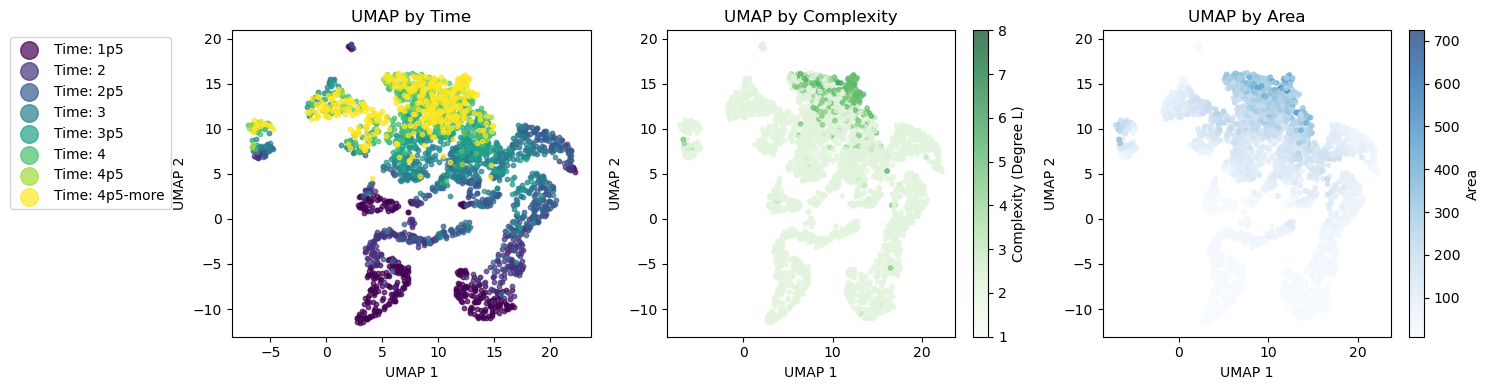

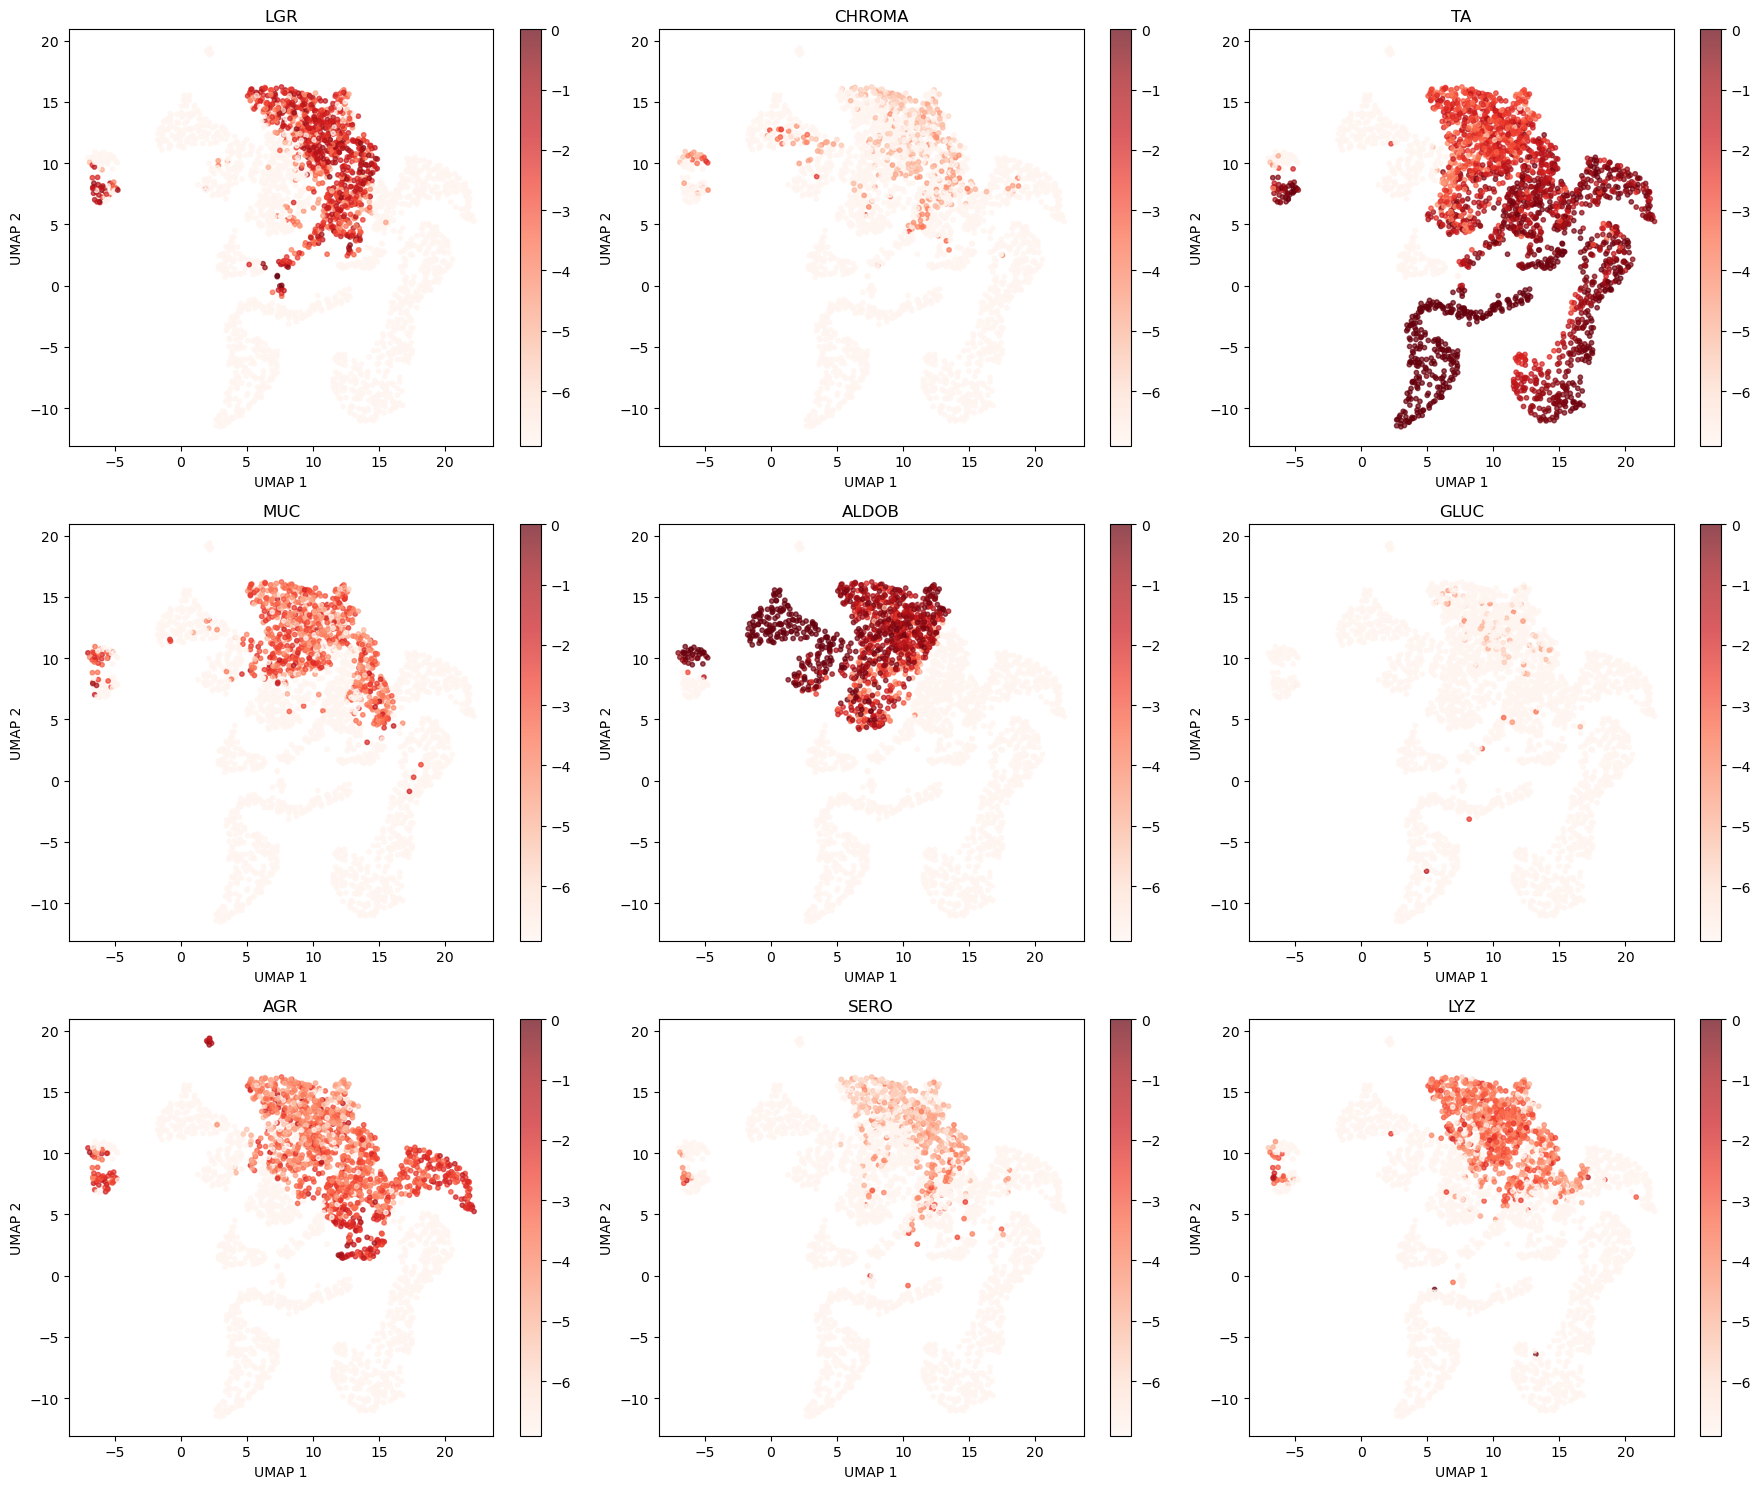

In [180]:
unique_times = np.unique(filtered_times)
point_size = 10

# Figure 1: Time and Complexity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cmap_time = plt.get_cmap('viridis')
for i, t in enumerate(unique_times):
    mask = filtered_times == t
    color = cmap_time(i / (len(unique_times) - 1))
    axes[0].scatter(X_emb[mask, 0], X_emb[mask, 1], color=color, alpha=0.7, s=point_size, label=f"Time: {t}")
axes[0].set_title(f'{method.upper()} by Time')
axes[0].set_xlabel(f'{method.upper()} 1')
axes[0].set_ylabel(f'{method.upper()} 2')
axes[0].legend(bbox_to_anchor=(-0.15, 1), loc='upper right', markerscale=4)

sc = axes[1].scatter(X_emb[:, 0], X_emb[:, 1], c=l_cross_values, cmap='Greens', alpha=0.7, s=point_size, vmin=1, vmax=8)
axes[1].set_title(f'{method.upper()} by Complexity')
axes[1].set_xlabel(f'{method.upper()} 1')
axes[1].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[1], label='Complexity (Degree L)')

sc = axes[2].scatter(X_emb[:, 0], X_emb[:, 1], c=filtered_areas, cmap='Blues', alpha=0.7, s=point_size)
axes[2].set_title(f'{method.upper()} by Area')
axes[2].set_xlabel(f'{method.upper()} 1')
axes[2].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[2], label='Area')

plt.tight_layout()
plt.show()

# Figure 2: Fate marker percentages (3x3)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

vmin = np.log(percentages_full + 1e-3).min()
vmax = np.log(percentages_full + 1e-3).max()

for i in range(percentages_full.shape[1]-1):
    sc = axes[i].scatter(X_emb[:, 0], X_emb[:, 1], c=np.log(percentages_full[:, i]+1e-3), cmap='Reds', alpha=0.7, s=point_size, vmin=vmin, vmax=vmax)
    axes[i].set_title(col_names[i])
    axes[i].set_xlabel(f'{method.upper()} 1')
    axes[i].set_ylabel(f'{method.upper()} 2')
    fig.colorbar(sc, ax=axes[i])

plt.tight_layout()
plt.show()